#Imports


In [1]:
# Visualisation Imports
import matplotlib.pyplot as plt        # For plotting and visualisations
import seaborn as sns                  # For statistical visualisations


# Preprocessing Imports
import pandas as pd                   #For data manipulation & analysis
import numpy as np                    #For numerical operations
from sklearn import preprocessing # Import the preprocessing module from scikit-learn for data transformation utilities
from collections import Counter # Import Counter to count occurrences of labels/classes in the dataset
from sklearn.preprocessing import StandardScaler # Import StandardScaler to normalize the feature values (mean = 0, std = 1)
from imblearn.over_sampling import SMOTE   #to balance our data using smote
from sklearn.model_selection import train_test_split # to split the data into test and train sets
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
)  #For performance metrics
from sklearn.preprocessing import LabelEncoder  # For label encoding


In [2]:
!pip install imbalanced-learn

In [3]:
# Modelling Imports
from sklearn.ensemble import RandomForestClassifier # Import the RandomForestClassifier model from scikit-learn
from sklearn.model_selection import GridSearchCV # Import GridSearchCV for hyperparameter tuning using cross-validation
import shap                            # For SHAP value analysis

m:\_Research\hellen-code-temp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
!pip install lime

In [5]:
from lime import lime_tabular

In [6]:
from lime.lime_tabular import LimeTabularExplainer


In [7]:
!pip install xgboost

In [8]:
from xgboost import XGBClassifier

#Dataset

In [9]:
# Load the dataset into a DataFrame
df = pd.read_csv("loans_data.csv")

In [10]:
# Display the first 5 rows of the dataset to understand its structure
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [11]:
# Check the shape of the dataset
df.shape

(614, 13)

In [12]:
#Check the data types
print(df.dtypes)

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object


In [13]:
# in the Dependents column, Replace '3+' with 3 and convert to numeric
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce')

In [14]:
print(df.dtypes)

Loan_ID                  str
Gender                   str
Married                  str
Dependents           float64
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object


#Visualisations


In [15]:
# Define the mapping for Credit_History
credit_history_map = {
    0.0: 'Bad Credit History',
    1.0: 'Good Credit History'
}

# Apply the mapping to the 'Credit_History' column
df['Credit_History'] = df['Credit_History'].map(credit_history_map)

In [16]:
# Define the mapping for Loan_Status
loan_status_map = {
    'Y': 'Yes',
    'N': 'No'
}

# Apply the mapping to the 'Loan_Status' column
df['Loan_Status'] = df['Loan_Status'].map(loan_status_map)

In [17]:
# Display the first 5 rows of the dataset
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,Good Credit History,Urban,Yes
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,Good Credit History,Rural,No
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,Good Credit History,Urban,Yes
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,Good Credit History,Urban,Yes
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,Good Credit History,Urban,Yes


Loan Status Distribution

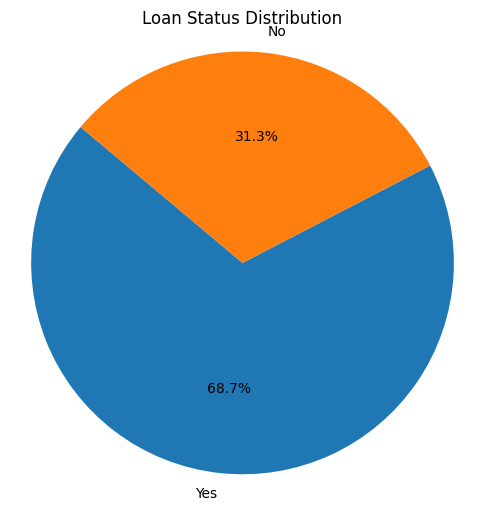

In [18]:
# Count the values in the 'loan_status' column
loan_status_counts = df['Loan_Status'].value_counts()

# Plot the pie chart
plt.figure(figsize=(6, 6))
plt.pie(loan_status_counts, labels=loan_status_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Loan Status Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

#autopct='%1.1f%%' shows percentages on the chart.
#startangle=140 rotates the start of the pie chart for aesthetics.

Histograms

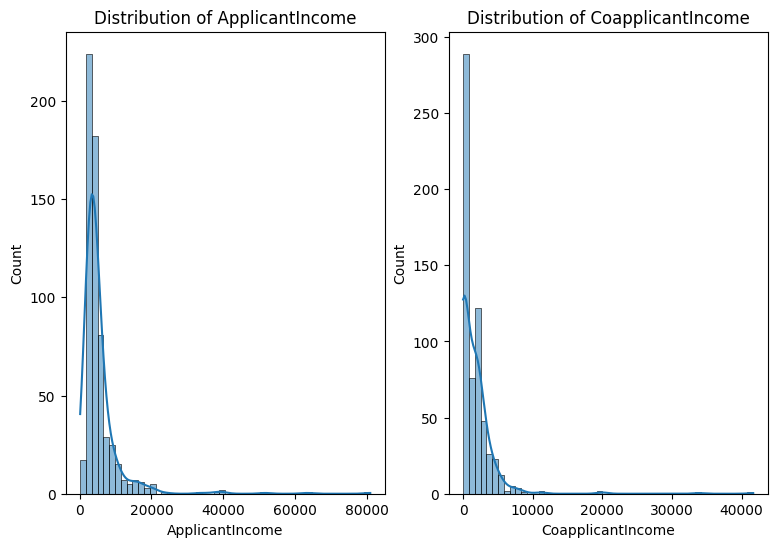

In [19]:
# Histograms for Applicant and Coapplicant Income
plt.figure(figsize=(14, 6))
for i, column in enumerate(['ApplicantIncome', 'CoapplicantIncome']):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
plt.show()

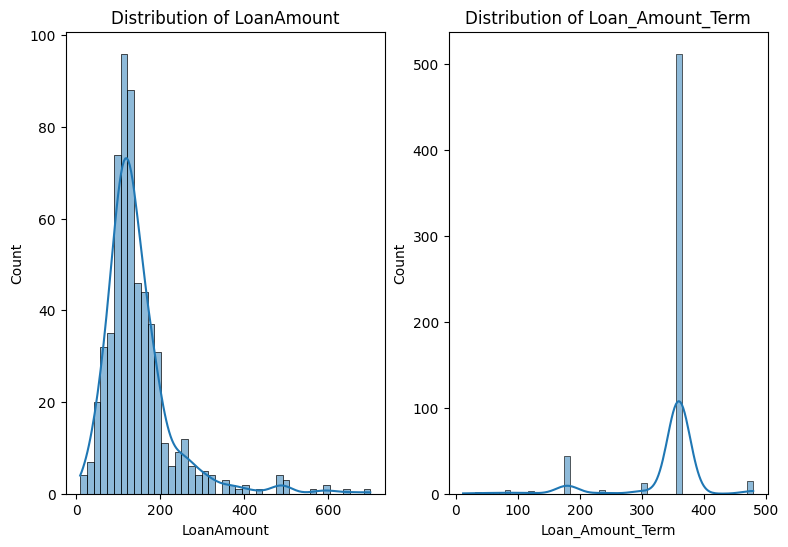

In [20]:
# Histograms for Loan Amount and Loan term
plt.figure(figsize=(14, 6))
for i, column in enumerate(['LoanAmount', 'Loan_Amount_Term']):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
plt.show()

Grouped Bar Charts

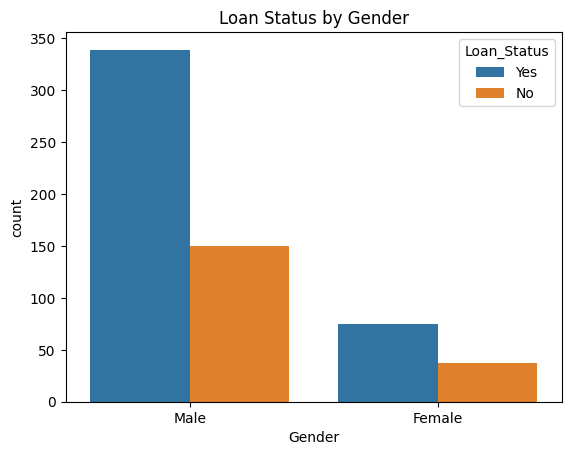

In [21]:
# Loan Status and Gender
sns.countplot(data=df, x='Gender', hue='Loan_Status')
plt.title("Loan Status by Gender")
plt.show()

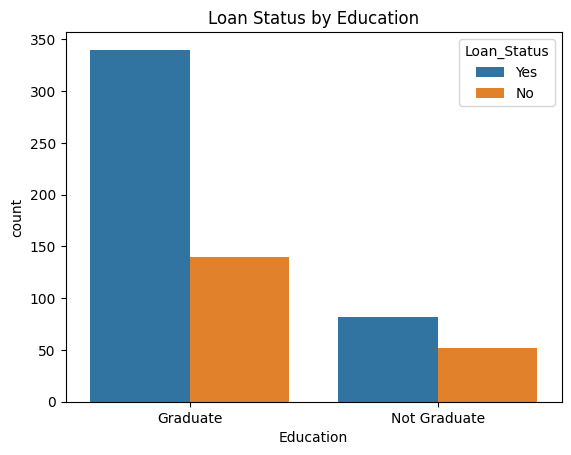

In [22]:
# Loan Status and Education
sns.countplot(data=df, x='Education', hue='Loan_Status')
plt.title("Loan Status by Education")
plt.show()


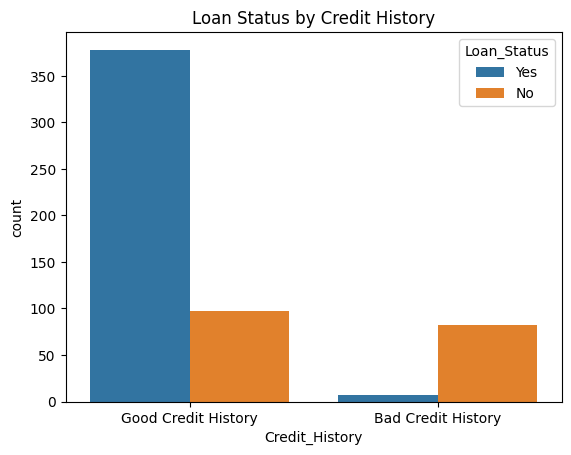

In [23]:
# Loan Status and Credit History
sns.countplot(data=df, x='Credit_History', hue='Loan_Status')
plt.title("Loan Status by Credit History")
plt.show()

# Correlation Analysis

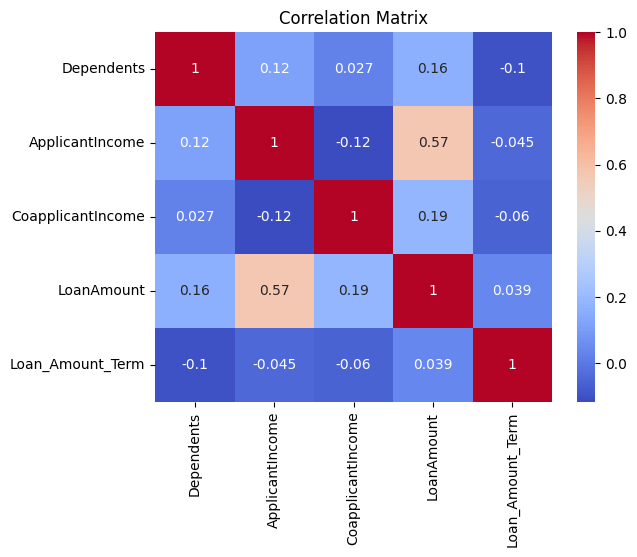

In [24]:
# Create the correlation matrix for all numeric features in the df
correlation_matrix = df.corr(numeric_only=True)

# Create a heatmap using seaborn to visualise the correlation matrix
# 'annot=True' displays the correlation coefficients inside the squares
# 'cmap="coolwarm"' sets the color scheme for better visual distinction of positive and negative correlations
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
# Add a title to the heatmap
plt.title("Correlation Matrix")

# Display the heatmap plot
plt.show()

#Descriptive Statistics

In [25]:
# Display summary statistics for numeric columns
df.describe()

,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,599.000000,614.000000,614.000000,592.000000,600.00000
mean,0.762938,5403.459283,1621.245798,146.412162,342.00000
std,1.015216,6109.041673,2926.248369,85.587325,65.12041
min,0.000000,150.000000,0.000000,9.000000,12.00000
25%,0.000000,2877.500000,0.000000,100.000000,360.00000
50%,0.000000,3812.500000,1188.500000,128.000000,360.00000
75%,2.000000,5795.000000,2297.250000,168.000000,360.00000
max,3.000000,81000.000000,41667.000000,700.000000,480.00000


In [26]:
# Basic statistics for categorical columns
df.describe(include=['object'])

C:\Users\misha\AppData\Local\Temp\ipykernel_92236\2132535628.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object'])


,Loan_ID,Gender,Married,Education,Self_Employed,Credit_History,Property_Area,Loan_Status
count,614,601,611,614,582,564,614,614
unique,614,2,2,2,2,2,3,2
top,LP001002,Male,Yes,Graduate,No,Good Credit History,Semiurban,Yes
freq,1,489,398,480,500,475,233,422


# Data Preprocessing

In [27]:
df = pd.read_csv("loans_data.csv")

In [28]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Dropping Noisy Attributes

In [29]:
# Drop 'Loan_ID' as it is a unique identifier and not useful for prediction
df = df.drop('Loan_ID', axis=1)

In [30]:
# in the Dependents column, Replace '3+' with 3 and convert to numeric
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce')

In [31]:
# Display the first 5 rows of the dataset
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Handling Missing Values

In [32]:
# Check for missing values in the dataset
df.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [33]:
# Using mode imputation for categorical features
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [34]:
# Using median imputation for numeric features
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())

In [35]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Label Encoding

In [36]:
# Encode categorical variables using Label Encoding

# Initiate the encoder
le = LabelEncoder()

# Apply label encoding to the 'Gender' column
df['Gender'] = le.fit_transform(df['Gender'])

# Apply label encoding to the 'Married' column
df['Married'] = le.fit_transform(df['Married'])

# Apply label encoding to the 'Education' column
df['Education'] = le.fit_transform(df['Education'])

# Apply label encoding to the 'Self_Employed' column
df['Self_Employed'] = le.fit_transform(df['Self_Employed'])

# Apply label encoding to the 'Property_Area' column
df['Property_Area'] = le.fit_transform(df['Property_Area'])

# Apply label encoding to the target variable 'Loan_Status'
df['Loan_Status'] = le.fit_transform(df['Loan_Status'])

In [37]:
# Display the first 5 rows of the dataset
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0.0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1.0,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0.0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0.0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0.0,0,0,6000,0.0,141.0,360.0,1.0,2,1


Balancing the classes and splitting the train and test sets

In [38]:
loan_status_count = df['Loan_Status'].value_counts()
print(loan_status_count)

Loan_Status
1    422
0    192
Name: count, dtype: int64


In [39]:
X = df.iloc[:, :-1].values    # predictor attributes
y = df.iloc[:,-1].values     # target attribute

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
oversample = SMOTE()
X_train_sm, y_train_sm = oversample.fit_resample(X_train, y_train) # using smote

In [41]:
# Check the value counts
count = Counter(y_train_sm)
count

Counter({np.int64(0): 342, np.int64(1): 342})

#Classification on the Loan_Status feature

# **1. Random Forest Model**

Feature Importance

In [42]:
# Fitting the RF model to the df before balancing
model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

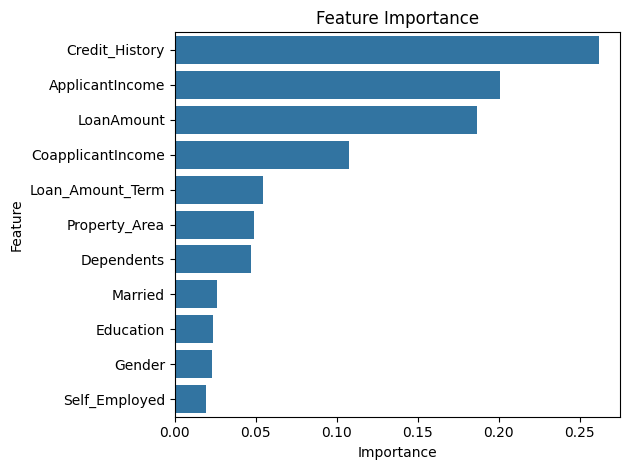

In [43]:
importances = model.feature_importances_

# Use original column names
feature_names = df.drop('Loan_Status', axis=1).columns

# Create and sort DataFrame
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

# **Random Forest with all features**



In [44]:
# Fitting the RF Model to the balanced data
model = RandomForestClassifier()
model.fit(X_train_sm, y_train_sm)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
from sklearn.model_selection import cross_val_predict

# Generate cross-validated predictions
y_pred_cv = cross_val_predict(model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC
y_proba_cv = cross_val_predict(model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# === Map class labels 0 -> 'No', 1 -> 'Yes' ===
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named = pd.Series(y_pred_cv).map(label_map)

# Confusion matrix
cm = confusion_matrix(y_true_named, y_pred_named)
print("Confusion Matrix:\n", cm)

# Accuracy
acc = accuracy_score(y_true_named, y_pred_named)
print("Accuracy:", acc)

# Precision
precision = precision_score(y_true_named, y_pred_named, pos_label='Yes')
print("Precision:", precision)

# Recall
recall = recall_score(y_true_named, y_pred_named, pos_label='Yes')
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_true_named, y_pred_named, pos_label='Yes')
print("F1 Score:", f1)

# AUC Score
auc = roc_auc_score(y_train_sm, y_proba_cv)
print("AUC Score:", auc)

# Full Classification Report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named))

Confusion Matrix:
 [[273  69]
 [ 28 314]]
Accuracy: 0.8581871345029239
Precision: 0.8198433420365535
Recall: 0.9181286549707602
F1 Score: 0.8662068965517241
AUC Score: 0.9047826681714032

Classification Report:
               precision    recall  f1-score   support

          No       0.91      0.80      0.85       342
         Yes       0.82      0.92      0.87       342

    accuracy                           0.86       684
   macro avg       0.86      0.86      0.86       684
weighted avg       0.86      0.86      0.86       684



# **Random Forest after feature selection**

In [46]:
# Before running this cell, drop noisy attributes, handle missing values, encode categorical features
# Drop low-importance features and retrain the model to compare performance
low_importance_features = ['Self_Employed', 'Gender', 'Education']
df_reduced = df.drop(columns=low_importance_features)

In [47]:
df_reduced.head()

,Married,Dependents,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,0.0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1.0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,0.0,3000,0.0,66.0,360.0,1.0,2,1
3,1,0.0,2583,2358.0,120.0,360.0,1.0,2,1
4,0,0.0,6000,0.0,141.0,360.0,1.0,2,1


In [48]:
loan_status_count = df_reduced['Loan_Status'].value_counts()
print(loan_status_count)

Loan_Status
1    422
0    192
Name: count, dtype: int64


In [49]:
X = df_reduced.iloc[:, :-1].values    # predictor attributes
y = df_reduced.iloc[:,-1].values     # target attribute

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
oversample = SMOTE()
X_train_sm, y_train_sm = oversample.fit_resample(X_train, y_train) # using smote

In [51]:
# Check the value counts
count = Counter(y_train_sm)
count

Counter({np.int64(0): 342, np.int64(1): 342})

In [52]:
# Fitting the RF Model to the balanced and scaled data after feature selection
model = RandomForestClassifier()
model.fit(X_train_sm, y_train_sm)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [53]:
# Generate cross-validated predictions
y_pred_cv = cross_val_predict(model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC
y_proba_cv = cross_val_predict(model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# === Map class labels 0 -> 'No', 1 -> 'Yes' ===
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named = pd.Series(y_pred_cv).map(label_map)

# Confusion matrix
cm = confusion_matrix(y_true_named, y_pred_named)
print("Confusion Matrix:\n", cm)

# Accuracy
acc = accuracy_score(y_true_named, y_pred_named)
print("Accuracy:", acc)

# Precision
precision = precision_score(y_true_named, y_pred_named, pos_label='Yes')
print("Precision:", precision)

# Recall
recall = recall_score(y_true_named, y_pred_named, pos_label='Yes')
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_true_named, y_pred_named, pos_label='Yes')
print("F1 Score:", f1)

# AUC Score
auc = roc_auc_score(y_train_sm, y_proba_cv)
print("AUC Score:", auc)

# Full Classification Report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named))

Confusion Matrix:
 [[267  75]
 [ 28 314]]
Accuracy: 0.8494152046783626
Precision: 0.8071979434447301
Recall: 0.9181286549707602
F1 Score: 0.8590971272229823
AUC Score: 0.8989945624294655

Classification Report:
               precision    recall  f1-score   support

          No       0.91      0.78      0.84       342
         Yes       0.81      0.92      0.86       342

    accuracy                           0.85       684
   macro avg       0.86      0.85      0.85       684
weighted avg       0.86      0.85      0.85       684



# **Hyperparameter Tuning for RF Model**

In [54]:
# Defining the parameter grid
param_grid = {
    'max_depth': [5, 10, 15, 20, None],  # Varying depth levels for different levels of complexity
    'n_estimators': [50, 100, 150],     # Number of trees in the forest
    'min_samples_split': [2, 10, 20],    # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],       # Minimum samples required at a leaf node
    'max_features': ['sqrt', 'log2'],    # Max number of features considered for splitting
    'bootstrap': [True, False]           # Whether bootstrap samples are used when building trees
}

# Creating the model
rf = RandomForestClassifier(random_state=42)

# Set up grid search for hyperparameter tuning
grid_search = GridSearchCV(
    estimator=rf,            # The base model: RandomForestClassifier
    param_grid=param_grid,   # Dictionary of hyperparameter(s) to test
    cv=5,                    # 5-fold cross-validation to evaluate each setting
    scoring='f1',            # Use f1 score to evaluate model performance
    n_jobs=-1,               # Use all available CPU cores for faster computation
    verbose=1                # Show progress of the grid search in the console
)

# Fitting the grid search to the data
grid_search.fit(X_train_sm, y_train_sm)

# Getting the best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)


Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Best Parameters: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
Best F1 Score: 0.880582168900746


In [55]:
# Training the final model with best parameters

final_model = RandomForestClassifier(
    bootstrap=False,          # No bootstrapping
    max_depth=10,             # Max depth of the trees
    max_features='sqrt',      # Max features considered for splitting
    min_samples_leaf=4,       # Minimum samples at leaf nodes
    min_samples_split=2,      # Minimum samples to split an internal node
    n_estimators=150,         # Number of trees in the forest
    random_state=42           # Ensuring reproducibility
)

# Fit the model to the balanced and scaled training data
final_model.fit(X_train_sm, y_train_sm)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [56]:
# Generate cross-validated predictions
y_pred_cv = cross_val_predict(final_model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC
y_proba_cv = cross_val_predict(final_model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# === Map class labels 0 -> 'No', 1 -> 'Yes' ===
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named = pd.Series(y_pred_cv).map(label_map)

# Confusion matrix
cm = confusion_matrix(y_true_named, y_pred_named)
print("Confusion Matrix:\n", cm)

# Accuracy
acc = accuracy_score(y_true_named, y_pred_named)
print("Accuracy:", acc)

# Precision
precision = precision_score(y_true_named, y_pred_named, pos_label='Yes')
print("Precision:", precision)

# Recall
recall = recall_score(y_true_named, y_pred_named, pos_label='Yes')
print("Recall:", recall)

# F1 Score
f1 = f1_score(y_true_named, y_pred_named, pos_label='Yes')
print("F1 Score:", f1)

# AUC Score
auc = roc_auc_score(y_train_sm, y_proba_cv)
print("AUC Score:", auc)

# Full Classification Report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named))

Confusion Matrix:
 [[260  82]
 [ 20 322]]
Accuracy: 0.8508771929824561
Precision: 0.7970297029702971
Recall: 0.9415204678362573
F1 Score: 0.8632707774798928
AUC Score: 0.9015680038302383

Classification Report:
               precision    recall  f1-score   support

          No       0.93      0.76      0.84       342
         Yes       0.80      0.94      0.86       342

    accuracy                           0.85       684
   macro avg       0.86      0.85      0.85       684
weighted avg       0.86      0.85      0.85       684



# **2. XGBoost Model**

In [57]:
#Creating and fitting the model
xgb_model = XGBClassifier(
    eval_metric='logloss',   # Recommended for binary classification
    random_state=42
)

xgb_model.fit(X_train_sm, y_train_sm)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [58]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

In [59]:
from sklearn.model_selection import cross_val_predict

# Generate cross-validated predictions (label predictions)
y_pred_cv_xgb = cross_val_predict(xgb_model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC (probability of class 1 — 'Yes')
y_proba_cv_xgb = cross_val_predict(xgb_model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# Map class labels 0 -> 'No', 1 -> 'Yes'
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named_xgb = pd.Series(y_pred_cv_xgb).map(label_map)

# Confusion matrix
cm_xgb = confusion_matrix(y_true_named, y_pred_named_xgb)
print("Confusion Matrix:\n", cm_xgb)

# Accuracy
acc_xgb = accuracy_score(y_true_named, y_pred_named_xgb)
print("Accuracy:", acc_xgb)

# Precision
precision_xgb = precision_score(y_true_named, y_pred_named_xgb, pos_label='Yes')
print("Precision:", precision_xgb)

# Recall
recall_xgb = recall_score(y_true_named, y_pred_named_xgb, pos_label='Yes')
print("Recall:", recall_xgb)

# F1 Score
f1_xgb = f1_score(y_true_named, y_pred_named_xgb, pos_label='Yes')
print("F1 Score:", f1_xgb)

# AUC Score
auc_xgb = roc_auc_score(y_train_sm, y_proba_cv_xgb)
print("AUC Score:", auc_xgb)

# Classification Report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named_xgb))

Confusion Matrix:
 [[273  69]
 [ 48 294]]
Accuracy: 0.8289473684210527
Precision: 0.8099173553719008
Recall: 0.8596491228070176
F1 Score: 0.8340425531914893
AUC Score: 0.8961304332957148

Classification Report:
               precision    recall  f1-score   support

          No       0.85      0.80      0.82       342
         Yes       0.81      0.86      0.83       342

    accuracy                           0.83       684
   macro avg       0.83      0.83      0.83       684
weighted avg       0.83      0.83      0.83       684



# **XGBOOST Hyperparameter Tuning**


In [60]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

In [61]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [62]:
grid_search.fit(X_train_sm, y_train_sm)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [63]:
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.8}
Best F1 Score: 0.8732343404552495


In [64]:
best_xgb_model = grid_search.best_estimator_

In [65]:
# Generate cross-validated predictions
y_pred_cv = cross_val_predict(best_xgb_model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC
y_proba_cv = cross_val_predict(best_xgb_model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# Map class labels
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named = pd.Series(y_pred_cv).map(label_map)

# Confusion matrix
cm = confusion_matrix(y_true_named, y_pred_named)
print("Confusion Matrix:\n", cm)

# Accuracy
print("Accuracy:", accuracy_score(y_true_named, y_pred_named))

# Precision
print("Precision:", precision_score(y_true_named, y_pred_named, pos_label='Yes'))

# Recall
print("Recall:", recall_score(y_true_named, y_pred_named, pos_label='Yes'))

# F1 Score
print("F1 Score:", f1_score(y_true_named, y_pred_named, pos_label='Yes'))

# AUC Score
print("AUC Score:", roc_auc_score(y_train_sm, y_proba_cv))

# Full report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named))

Confusion Matrix:
 [[258  84]
 [ 17 325]]
Accuracy: 0.8523391812865497
Precision: 0.7946210268948656
Recall: 0.9502923976608187
F1 Score: 0.8655126498002663
AUC Score: 0.8973701309804726

Classification Report:
               precision    recall  f1-score   support

          No       0.94      0.75      0.84       342
         Yes       0.79      0.95      0.87       342

    accuracy                           0.85       684
   macro avg       0.87      0.85      0.85       684
weighted avg       0.87      0.85      0.85       684



# **3. Ensemble Model**

# **Stacking Ensemble Model**

In [66]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

In [67]:
# Base learners
estimators = [
    ('rf', final_model),  # already tuned
    ('xgb', best_xgb_model)  # already tuned
]

# Meta-learner (final estimator)
meta_learner = LogisticRegression()

# Stacking classifier
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1,
    passthrough=False
)

In [68]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# Cross-validated predictions
y_pred_cv_stack = cross_val_predict(stacking_model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC
y_proba_cv_stack = cross_val_predict(stacking_model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# Map labels
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named_stack = pd.Series(y_pred_cv_stack).map(label_map)

# Metrics
cm_stack = confusion_matrix(y_true_named, y_pred_named_stack)
print("Confusion Matrix:\n", cm_stack)

acc_stack = accuracy_score(y_true_named, y_pred_named_stack)
print("Accuracy:", acc_stack)

precision_stack = precision_score(y_true_named, y_pred_named_stack, pos_label='Yes')
print("Precision:", precision_stack)

recall_stack = recall_score(y_true_named, y_pred_named_stack, pos_label='Yes')
print("Recall:", recall_stack)

f1_stack = f1_score(y_true_named, y_pred_named_stack, pos_label='Yes')
print("F1 Score:", f1_stack)

auc_stack = roc_auc_score(y_train_sm, y_proba_cv_stack)
print("AUC Score:", auc_stack)

print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named_stack))

Confusion Matrix:
 [[266  76]
 [ 25 317]]
Accuracy: 0.8523391812865497
Precision: 0.806615776081425
Recall: 0.9269005847953217
F1 Score: 0.8625850340136054
AUC Score: 0.897994254642454

Classification Report:
               precision    recall  f1-score   support

          No       0.91      0.78      0.84       342
         Yes       0.81      0.93      0.86       342

    accuracy                           0.85       684
   macro avg       0.86      0.85      0.85       684
weighted avg       0.86      0.85      0.85       684



# **Voting Ensemble** **Model**

In [69]:
from sklearn.ensemble import VotingClassifier

# Build the voting ensemble
ensemble_model = VotingClassifier(
    estimators=[('rf', final_model), ('xgb', xgb_model)],
    voting='soft'
)

# Fit the ensemble model
ensemble_model.fit(X_train_sm, y_train_sm)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('rf', ...), ('xgb', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4


In [70]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

# Generate cross-validated predictions (label predictions)
y_pred_cv_ens = cross_val_predict(ensemble_model, X_train_sm, y_train_sm, cv=5, method='predict')

# Probabilities for AUC (probability of class 1 — 'Yes')
y_proba_cv_ens = cross_val_predict(ensemble_model, X_train_sm, y_train_sm, cv=5, method='predict_proba')[:, 1]

# Map class labels 0 -> 'No', 1 -> 'Yes'
label_map = {0: 'No', 1: 'Yes'}
y_true_named = pd.Series(y_train_sm).map(label_map)
y_pred_named_ens = pd.Series(y_pred_cv_ens).map(label_map)

# Confusion matrix
cm_ens = confusion_matrix(y_true_named, y_pred_named_ens)
print("Confusion Matrix:\n", cm_ens)

# Accuracy
acc_ens = accuracy_score(y_true_named, y_pred_named_ens)
print("Accuracy:", acc_ens)

# Precision
precision_ens = precision_score(y_true_named, y_pred_named_ens, pos_label='Yes')
print("Precision:", precision_ens)

# Recall
recall_ens = recall_score(y_true_named, y_pred_named_ens, pos_label='Yes')
print("Recall:", recall_ens)

# F1 Score
f1_ens = f1_score(y_true_named, y_pred_named_ens, pos_label='Yes')
print("F1 Score:", f1_ens)

# AUC Score
auc_ens = roc_auc_score(y_train_sm, y_proba_cv_ens)
print("AUC Score:", auc_ens)

# Classification Report
print("\nClassification Report:\n", classification_report(y_true_named, y_pred_named_ens))

Confusion Matrix:
 [[271  71]
 [ 32 310]]
Accuracy: 0.8494152046783626
Precision: 0.8136482939632546
Recall: 0.9064327485380117
F1 Score: 0.8575380359612724
AUC Score: 0.9011319722307718

Classification Report:
               precision    recall  f1-score   support

          No       0.89      0.79      0.84       342
         Yes       0.81      0.91      0.86       342

    accuracy                           0.85       684
   macro avg       0.85      0.85      0.85       684
weighted avg       0.85      0.85      0.85       684



## Statistical Rigor Analysis

In [71]:
from scipy.stats import ttest_rel, wilcoxon
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [72]:
def compute_variance_analysis(models, X_train_sm, y_train_sm):
    # Initialize CV strategy
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Initialize results storage
    results = []
    f1_scores_dict = {}
    
    # Compute metrics for each model
    for model_name, model in models:
        # Compute per-fold scores for each metric
        accuracy_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv_strategy, scoring='accuracy')
        precision_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv_strategy, scoring='precision')
        recall_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv_strategy, scoring='recall')
        f1_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv_strategy, scoring='f1')
        auc_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv_strategy, scoring='roc_auc')
        
        # Store F1 scores for reuse in significance testing
        f1_scores_dict[model_name] = f1_scores
        
        # Format results as mean ± std with 2 decimal places
        results.append({
            'Model': model_name,
            'Accuracy': f"{accuracy_scores.mean():.2f} ± {accuracy_scores.std():.2f}",
            'Precision': f"{precision_scores.mean():.2f} ± {precision_scores.std():.2f}",
            'Recall': f"{recall_scores.mean():.2f} ± {recall_scores.std():.2f}",
            'F1': f"{f1_scores.mean():.2f} ± {f1_scores.std():.2f}",
            'AUC': f"{auc_scores.mean():.2f} ± {auc_scores.std():.2f}"
        })
    
    # Create DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df, f1_scores_dict

In [73]:
def compute_significance_testing(models, X_train_sm, y_train_sm, f1_scores_dict=None):
    from itertools import combinations
    
    # If f1_scores_dict not provided, compute per-fold F1 scores
    if f1_scores_dict is None:
        # Initialize CV strategy (same as variance analysis)
        cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        
        # Collect per-fold F1 scores for all models
        f1_scores_dict = {}
        for model_name, model in models:
            f1_scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv_strategy, scoring='f1')
            f1_scores_dict[model_name] = f1_scores
    
    # Extract model names
    model_names = [name for name, _ in models]
    
    # Generate all pairwise combinations
    model_pairs = list(combinations(model_names, 2))
    
    # Initialize results matrix as a dictionary
    results = {}
    for name in model_names:
        results[name] = {}
    
    # Perform pairwise comparisons
    for model_A, model_B in model_pairs:
        # Get per-fold F1 scores
        scores_A = f1_scores_dict[model_A]
        scores_B = f1_scores_dict[model_B]
        
        # Perform paired t-test (primary)
        t_statistic, p_value_ttest = ttest_rel(scores_A, scores_B)
        
        # Perform Wilcoxon signed-rank test (supplementary)
        w_statistic, p_value_wilcoxon = wilcoxon(scores_A, scores_B)
        
        # Determine significance (using t-test as primary)
        is_significant = (p_value_ttest < 0.05)
        
        # Format result with both p-values
        if is_significant:
            result_string = f"t: p={p_value_ttest:.4f}*, W: p={p_value_wilcoxon:.4f}"
        else:
            result_string = f"t: p={p_value_ttest:.4f}, W: p={p_value_wilcoxon:.4f}"
        
        # Add to results matrix (symmetric)
        results[model_A][model_B] = result_string
        results[model_B][model_A] = result_string
    
    # Fill diagonal with dashes
    for name in model_names:
        results[name][name] = "—"
    
    # Create DataFrame
    results_df = pd.DataFrame(results).T
    results_df = results_df[model_names]  # Ensure column order matches row order
    
    return results_df

In [74]:
# Create list of models for analysis
models = [
    ('Tuned RF', final_model),
    ('Tuned XGBoost', best_xgb_model),
    ('Stacking', stacking_model),
    ('Voting', ensemble_model)
]

# Execute variance analysis
variance_results_df, f1_scores_dict = compute_variance_analysis(models, X_train_sm, y_train_sm)

# Display results
print("\n=== Variance Analysis Results ===")
print(variance_results_df.to_string(index=False))


=== Variance Analysis Results ===
        Model    Accuracy   Precision      Recall          F1         AUC
     Tuned RF 0.85 ± 0.03 0.80 ± 0.04 0.94 ± 0.02 0.87 ± 0.02 0.91 ± 0.03
Tuned XGBoost 0.85 ± 0.03 0.79 ± 0.04 0.94 ± 0.03 0.86 ± 0.02 0.91 ± 0.04
     Stacking 0.85 ± 0.04 0.81 ± 0.05 0.92 ± 0.03 0.86 ± 0.03 0.91 ± 0.04
       Voting 0.85 ± 0.04 0.81 ± 0.05 0.91 ± 0.03 0.86 ± 0.04 0.90 ± 0.04


### Variance Analysis Interpretation

In [75]:
# Execute significance testing using the same models list and F1 scores from variance analysis
significance_results_df = compute_significance_testing(models, X_train_sm, y_train_sm, f1_scores_dict)

# Display results
print("\n=== Statistical Significance Testing Results ===")
print(significance_results_df)


=== Statistical Significance Testing Results ===
                               Tuned RF             Tuned XGBoost  \
Tuned RF                              —  t: p=0.4129, W: p=0.6250   
Tuned XGBoost  t: p=0.4129, W: p=0.6250                         —   
Stacking       t: p=0.3627, W: p=0.4375  t: p=0.8827, W: p=1.0000   
Voting         t: p=0.2793, W: p=0.3125  t: p=0.6827, W: p=1.0000   

                               Stacking                    Voting  
Tuned RF       t: p=0.3627, W: p=0.4375  t: p=0.2793, W: p=0.3125  
Tuned XGBoost  t: p=0.8827, W: p=1.0000  t: p=0.6827, W: p=1.0000  
Stacking                              —  t: p=0.4385, W: p=0.6250  
Voting         t: p=0.4385, W: p=0.6250                         —  


### Statistical Significance Testing Interpretation

In [76]:
def compute_cv_metrics(model, X, y, cv_strategy):
    # Compute per-fold scores for each metric
    accuracy_scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='accuracy')
    precision_scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='precision')
    recall_scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='recall')
    f1_scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='f1')
    auc_scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='roc_auc')
    
    # Return dictionary with formatted strings and raw F1 mean
    return {
        'accuracy': f"{accuracy_scores.mean():.2f} ± {accuracy_scores.std():.2f}",
        'precision': f"{precision_scores.mean():.2f} ± {precision_scores.std():.2f}",
        'recall': f"{recall_scores.mean():.2f} ± {recall_scores.std():.2f}",
        'f1': f"{f1_scores.mean():.2f} ± {f1_scores.std():.2f}",
        'auc': f"{auc_scores.mean():.2f} ± {auc_scores.std():.2f}",
        'f1_mean': f1_scores.mean()  # Raw mean for delta calculation
    }

In [77]:
def compute_ablation_study(X_train, y_train, X_train_sm, y_train_sm, X_train_sm_full, y_train_sm_full, final_model):
    from sklearn.ensemble import RandomForestClassifier
    
    # Initialize CV strategy (same as other modules)
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Compute baseline metrics (full pipeline: SMOTE + tuned model + feature selection)
    print("Computing baseline metrics (Full Pipeline: SMOTE + Tuned RF + Feature Selection)...")
    baseline_metrics = compute_cv_metrics(final_model, X_train_sm, y_train_sm, cv_strategy)
    baseline_f1_mean = baseline_metrics['f1_mean']
    
    # Ablation 1: No SMOTE (remove SMOTE, keep tuning and feature selection)
    print("Computing No SMOTE ablation metrics...")
    no_smote_metrics = compute_cv_metrics(final_model, X_train, y_train, cv_strategy)
    no_smote_f1_mean = no_smote_metrics['f1_mean']
    delta_no_smote = baseline_f1_mean - no_smote_f1_mean
    
    # Ablation 2: No Hyperparameter Tuning (remove tuning, keep SMOTE and feature selection)
    print("Computing No Hyperparameter Tuning ablation metrics...")
    default_rf = RandomForestClassifier(random_state=42)
    no_tuning_metrics = compute_cv_metrics(default_rf, X_train_sm, y_train_sm, cv_strategy)
    no_tuning_f1_mean = no_tuning_metrics['f1_mean']
    delta_no_tuning = baseline_f1_mean - no_tuning_f1_mean
    
    # Ablation 3: No Feature Selection (remove feature selection, keep SMOTE and tuning)
    print("Computing No Feature Selection ablation metrics...")
    no_fs_metrics = compute_cv_metrics(final_model, X_train_sm_full, y_train_sm_full, cv_strategy)
    no_fs_f1_mean = no_fs_metrics['f1_mean']
    delta_no_fs = baseline_f1_mean - no_fs_f1_mean
    
    # Helper function to format delta
    def format_delta(delta):
        if delta > 0:
            return f"-{delta:.2f}"  # negative impact (performance decreased)
        elif delta < 0:
            return f"+{abs(delta):.2f}"  # positive impact (performance increased)
        else:
            return "0.00"
    
    # Create results DataFrame
    results_data = [
        {
            'Condition': 'Baseline (Full Pipeline)',
            'Accuracy': baseline_metrics['accuracy'],
            'Precision': baseline_metrics['precision'],
            'Recall': baseline_metrics['recall'],
            'F1': baseline_metrics['f1'],
            'AUC': baseline_metrics['auc'],
            'Delta_F1': '—'
        },
        {
            'Condition': 'No SMOTE',
            'Accuracy': no_smote_metrics['accuracy'],
            'Precision': no_smote_metrics['precision'],
            'Recall': no_smote_metrics['recall'],
            'F1': no_smote_metrics['f1'],
            'AUC': no_smote_metrics['auc'],
            'Delta_F1': format_delta(delta_no_smote)
        },
        {
            'Condition': 'No Hyperparameter Tuning',
            'Accuracy': no_tuning_metrics['accuracy'],
            'Precision': no_tuning_metrics['precision'],
            'Recall': no_tuning_metrics['recall'],
            'F1': no_tuning_metrics['f1'],
            'AUC': no_tuning_metrics['auc'],
            'Delta_F1': format_delta(delta_no_tuning)
        },
        {
            'Condition': 'No Feature Selection',
            'Accuracy': no_fs_metrics['accuracy'],
            'Precision': no_fs_metrics['precision'],
            'Recall': no_fs_metrics['recall'],
            'F1': no_fs_metrics['f1'],
            'AUC': no_fs_metrics['auc'],
            'Delta_F1': format_delta(delta_no_fs)
        }
    ]
    
    results_df = pd.DataFrame(results_data)
    
    return results_df

### Ablation Study

In [78]:
# Prepare data for No Feature Selection ablation
# We need SMOTE-balanced data with all 12 original features (before feature selection)
from imblearn.over_sampling import SMOTE

# Get original features (all 12 features from df, not df_reduced)
X_original = df.iloc[:, :-1].values
y_original = df.iloc[:, -1].values

# Split with same random_state to ensure consistency
from sklearn.model_selection import train_test_split
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X_original, y_original, test_size=0.2, random_state=42
)

# Apply SMOTE to the full feature set
smote_full = SMOTE(random_state=42)
X_train_sm_full, y_train_sm_full = smote_full.fit_resample(X_train_original, y_train_original)

print(f"Original X_train shape (with feature selection): {X_train.shape}")
print(f"Full X_train_sm_full shape (all features): {X_train_sm_full.shape}")
print(f"Features removed by feature selection: {X_train_sm_full.shape[1] - X_train.shape[1]}")

Original X_train shape (with feature selection): (491, 8)
Full X_train_sm_full shape (all features): (684, 11)
Features removed by feature selection: 3


In [79]:
# Execute ablation study
ablation_results = compute_ablation_study(
    X_train=X_train,
    y_train=y_train,
    X_train_sm=X_train_sm,
    y_train_sm=y_train_sm,
    X_train_sm_full=X_train_sm_full,
    y_train_sm_full=y_train_sm_full,
    final_model=final_model
)

# Display results
ablation_results

Computing baseline metrics (Full Pipeline: SMOTE + Tuned RF + Feature Selection)...
Computing No SMOTE ablation metrics...
Computing No Hyperparameter Tuning ablation metrics...
Computing No Feature Selection ablation metrics...


,Condition,Accuracy,Precision,Recall,F1,AUC,Delta_F1
0,Baseline (Full Pipeline),0.85 ± 0.03,0.80 ± 0.04,0.94 ± 0.02,0.87 ± 0.02,0.91 ± 0.03,—
1,No SMOTE,0.81 ± 0.03,0.81 ± 0.02,0.96 ± 0.01,0.88 ± 0.02,0.77 ± 0.05,+0.01
2,No Hyperparameter Tuning,0.85 ± 0.03,0.80 ± 0.04,0.92 ± 0.02,0.86 ± 0.03,0.90 ± 0.04,-0.01
3,No Feature Selection,0.86 ± 0.03,0.80 ± 0.03,0.94 ± 0.02,0.87 ± 0.02,0.90 ± 0.04,+0.00


# **LIME explanation for Random Forest Tuned Model**

In [80]:
# Get feature names if you dropped 'Loan_Status'
feature_names = df_reduced.drop('Loan_Status', axis=1).columns.tolist()

explainer = LimeTabularExplainer(
    training_data=X_train_sm,
    feature_names=feature_names,
    class_names=['No', 'Yes'],
    mode='classification',
    discretize_continuous=True
)

In [81]:
#Choose an instance to explain
i = 4  # for example
instance = X_train_sm[i]

In [82]:
explanation = explainer.explain_instance(
    data_row=instance,
    predict_fn=final_model.predict_proba,
    num_features=10
)
explanation.show_in_notebook()

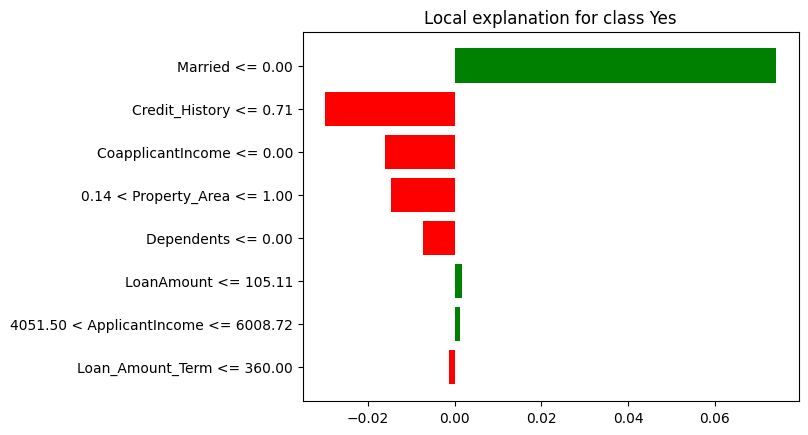

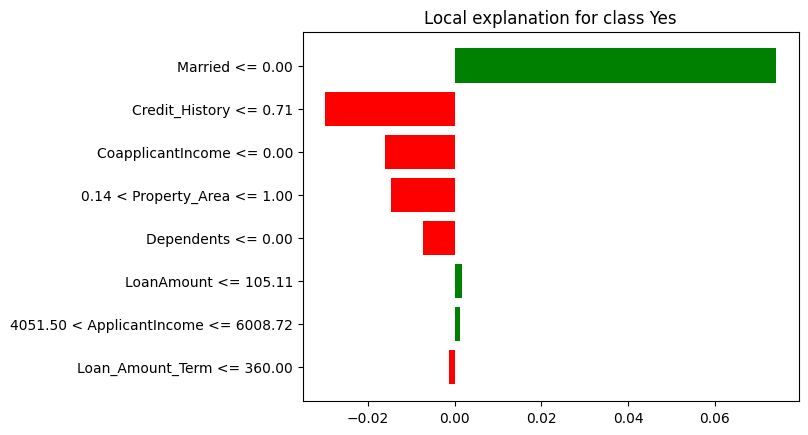

In [83]:
explanation.as_pyplot_figure()

In [84]:
#Choose an instance to explain
i = 6  # for example
instance = X_train_sm[i]

In [85]:
explanation = explainer.explain_instance(
    data_row=instance,
    predict_fn=final_model.predict_proba,
    num_features=10
)
explanation.show_in_notebook()

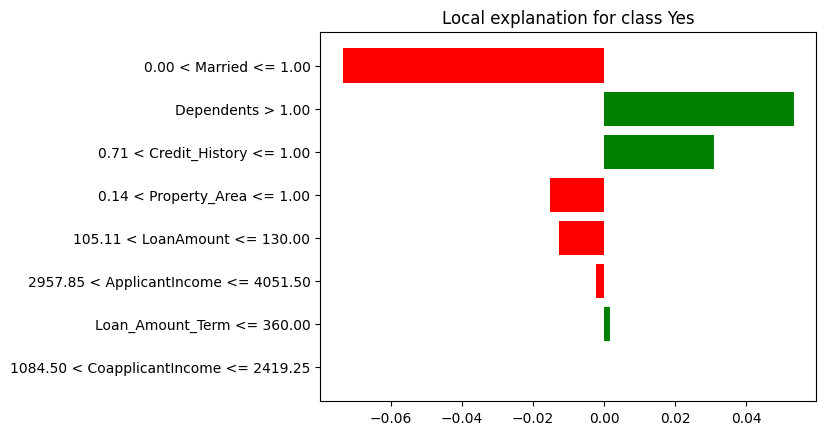

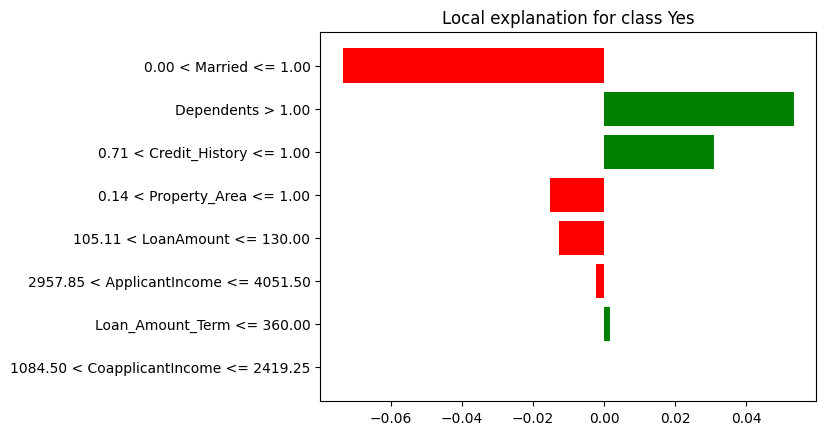

In [86]:
explanation.as_pyplot_figure()